# 1. Veri Keşfi ve İlk Analiz (Exploratory Data Analysis - EDA)

Bu notebook içerisinde, **Autoflow-Sync** akıllı lojistik ve tedarik zinciri optimizasyon projemizin temelini oluşturacak olan ham veri setini inceliyoruz. 

### Amaçlarımız:
1. Veri setinin genel boyutunu ve yapısını anlamak.
2. Otomotiv lojistiğinde kullanacağımız kritik değişkenleri (sütunları) tespit etmek.
3. Eksik (null) veya hatalı verilerin varlığını kontrol ederek ön işleme (preprocessing) stratejimizi belirlemek.

In [1]:
import pandas as pd
import numpy as np
import os

# Veri setinin projedeki konumunu dinamik olarak tanımlıyoruz
data_path = os.path.join("..", "..", "..", "data", "raw", "smart_logistics_dataset.csv")

# CSV dosyasını hafızaya (DataFrame) yüklüyoruz
df = pd.read_csv(data_path)

# Yapısal boyut bilgilerini ekrana yazdırıyoruz
print(f"Sistem Bilgisi: Veri seti {df.shape[0]} satır ve {df.shape[1]} sütundan oluşuyor.\n")

Sistem Bilgisi: Veri seti 1000 satır ve 16 sütundan oluşuyor.



Sistemimiz 1000 farklı lojistik hareketi (örneğin kamyon seferi, parça taşıma vb.) ve bu hareketlere ait 16 farklı özelliği barındırıyor. Kurumsal bir yapay zeka modeli eğitmek ve rota optimizasyonu yapmak için başlangıç seviyesinde oldukça dengeli ve yeterli bir veri hacmine sahibiz.

## 1.1. Veri Setinin İlk Satırlarının İncelenmesi

Verinin genel içeriğini, sütunların ne tür değerler aldığını ve lojistik akışın nasıl kaydedildiğini gözlemlemek adına ilk 5 satıra göz atıyoruz.

In [2]:
# Verinin ilk 5 satırını tablo halinde görüntülüyoruz
df.head()

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


Veride doğrudan otomotiv tedarik zincirini etkileyen unsurlar var. Örneğin, 0. satırdaki Truck_7, 390 adet parça taşıyor, yolda bir engelle (Detour) karşılaşmış, 38 dakika beklemiş ve sonuç olarak sevkiyat gecikmiş (Logistics_Delay = 1). Bu bize trafiğin ve bekleme sürelerinin gecikmeler üzerinde güçlü bir etkisi olduğunu gösteriyor.

## 1.2. Veri Tipleri ve Eksik Değer Kontrolü

Bu aşamada veri setindeki her bir sütunun veri tipini (sayısal, metinsel, tarih vb.) ve temizleme (preprocessing) aşamasında doldurmamız veya silmemiz gereken eksik (null) satırların oranını inceliyoruz.

In [3]:
# Sütun bazlı veri tiplerini ve eksik değer sayılarını analiz ediyoruz
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                1000 non-null   str    
 1   Asset_ID                 1000 non-null   str    
 2   Latitude                 1000 non-null   float64
 3   Longitude                1000 non-null   float64
 4   Inventory_Level          1000 non-null   int64  
 5   Shipment_Status          1000 non-null   str    
 6   Temperature              1000 non-null   float64
 7   Humidity                 1000 non-null   float64
 8   Traffic_Status           1000 non-null   str    
 9   Waiting_Time             1000 non-null   int64  
 10  User_Transaction_Amount  1000 non-null   int64  
 11  User_Purchase_Frequency  1000 non-null   int64  
 12  Logistics_Delay_Reason   737 non-null    str    
 13  Asset_Utilization        1000 non-null   float64
 14  Demand_Forecast          1000 non-nu

Veri setimizde sadece Logistics_Delay_Reason sütununda eksik veri var. Ancak buradaki eksiklik sistemsel bir hata değil, mantıksal bir sonuçtur. Eğer sevkiyat zamanında teslim edildiyse (Logistics_Delay = 0), doğal olarak bir gecikme nedeni girilmemiştir ve veri boş kalmıştır. Preprocessing (Ön İşleme) aşamasında bu boş değerleri silmek yerine, buralara 'No Delay' (Gecikme Yok) yazarak veriyi anlamlı hale getireceğim.

## 1.3. İstatistiksel Genel Bakış ve Sayısal Dağılımlar

Veri setindeki sayısal kolonların (Örn: Stok miktarları, teslimat süreleri, maliyetler vb.) ortalama, minimum, maksimum ve çeyreklik (özellikle aykırı değer tespiti için %25 ve %75) değerlerini inceleyerek verinin dağılımı hakkında fikir sahibi oluyoruz.

In [13]:
# Sayısal sütunların temel istatistiksel özetini çıkarıyoruz
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,1000.0,-1.360093,51.997183,-89.7915,-46.167975,-4.50315,44.50280,89.8701
Longitude,1000.0,0.837049,104.843618,-179.8202,-88.448075,0.67830,88.15645,179.9237
Inventory_Level,1000.0,297.915000,113.554773,100.0000,201.000000,299.00000,399.00000,500.0000
Temperature,1000.0,23.893900,3.322178,18.0000,21.200000,23.80000,26.60000,30.0000
Humidity,1000.0,65.042200,8.753765,50.0000,57.200000,65.20000,72.40000,80.0000
Waiting_Time,1000.0,35.062000,14.477768,10.0000,23.000000,35.00000,49.00000,60.0000
User_Transaction_Amount,1000.0,299.055000,117.787792,100.0000,191.750000,301.50000,405.00000,500.0000
User_Purchase_Frequency,1000.0,5.513000,2.935379,1.0000,3.000000,6.00000,8.00000,10.0000
Asset_Utilization,1000.0,79.599100,11.631153,60.0000,69.475000,79.25000,89.42500,100.0000
Demand_Forecast,1000.0,199.284000,59.920847,100.0000,144.000000,202.00000,251.25000,300.0000


*Inventory_Level (Stok): Ortalama stok 297 adet. Depolarda en az 100, en fazla 500 parça tutuluyor. Stok yönetimimiz 100-500 bandında sınırlandırılmış.

*Waiting_Time (Bekleme Süresi): Araçlar yükleme/boşaltma veya kapılarda ortalama 35 dakika bekliyor (En fazla 60 dakika). Bu süre yalın üretim için ciddi bir kayıptır. 

*Asset_Utilization (Araç Kapasite Kullanımı): Kamyonların doluluk oranı ortalama %79.5. Yani kamyonları %20 civarında boş gezdiriyoruz, bu da lojistik maliyetini artırıyor. 

*Logistics_Delay (Gecikme): Ortalama değer 0.56. Bu, veri setindeki sevkiyatların %56.6'sının geciktiğini gösteriyor.

Yani karşımızda çözülmesi gereken çok ciddi bir lojistik krizi var ve eğiteceğimiz model bu yüzden çok değerli.

## 1.4. Kategorik Değişkenlerin Dağılımı

Otomotiv lojistiğinde tedarikçiler, parça kategorileri veya gönderim modları gibi kategorik (metinsel) verilerin benzersiz (unique) değer sayılarını ve en sık tekrar eden sınıflarını analiz ediyoruz.

In [9]:
# Uyarıyı engellemek için hem 'object' hem de 'string' tiplerini açıkça belirtiyoruz
df.describe(include=['object', 'string']).T

,count,unique,top,freq
Timestamp,1000,1000,2024-03-20 00:11:14,1
Asset_ID,1000,10,Truck_8,109
Shipment_Status,1000,3,Delayed,350
Traffic_Status,1000,3,Detour,345
Logistics_Delay_Reason,737,3,Weather,267


Fabrikaya parça getiren kamyonların gecikmesindeki en büyük dışsal etken kötü hava koşulları ve yoldaki mecburi rota sapmalarıdır. Yapay zeka modelimiz bu iki değişkeni kullanarak gelecekteki gecikmeleri başarıyla tahmin edebilir.

## 1.5. Veri Görselleştirme (Data Visualization)

Sayısal verilerin dağılımını, lojistik süreçlerdeki darboğazları ve tedarik zincirindeki düzensizlikleri daha net görebilmek adına görsel analiz aşamasına geçiyoruz. 

### Bu Aşamada İnceleyeceğimiz Grafikler:
1. **Lojistik Bekleme Süreleri (Waiting Time) Dağılımı:** Araçların operasyon sırasında ne kadar beklediğini ve bu sürelerin yoğunlaştığı alanları inceleyeceğiz.
2. **Kritik Stok Seviyeleri (Inventory Level):** Depolardaki parça miktarlarının dağılımını ve parçasız kalma (veya aşırı stok) risklerini göreceğiz.
3. **Bekleme Süresi ve İşlem Maliyeti İlişkisi (Scatter Plot):** Lojistikteki bekleme sürelerinin sevkiyat maliyetlerine olan etkisini ve bu iki değişkenin gecikme durumuyla (`Logistics_Delay`) ilişkisini analiz edeceğiz.

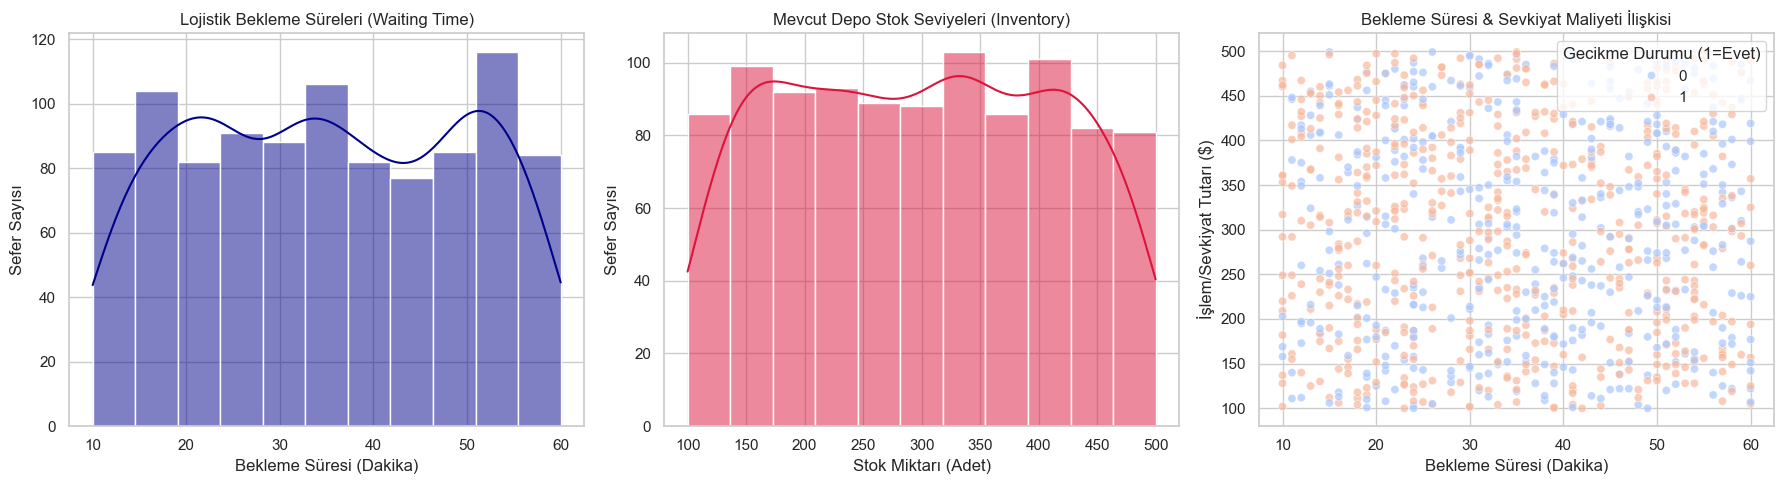

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin profesyonel ve temiz görünmesi için seaborn temasını ayarlıyoruz
sns.set_theme(style="whitegrid")

# Bu kez 3 grafik çizeceğimiz için dikeyde daha geniş bir alan (18, 5) kurguluyoruz
plt.figure(figsize=(18, 5))

# 1. Grafik: Bekleme Süreleri Dağılımı (Waiting Time)
plt.subplot(1, 3, 1)
sns.histplot(df['Waiting_Time'], kde=True, color="darkblue")
plt.title("Lojistik Bekleme Süreleri (Waiting Time)", fontsize=12)
plt.xlabel("Bekleme Süresi (Dakika)")
plt.ylabel("Sefer Sayısı")

# 2. Grafik: Stok Seviyeleri Dağılımı (Inventory Level)
plt.subplot(1, 3, 2)
sns.histplot(df['Inventory_Level'], kde=True, color="crimson")
plt.title("Mevcut Depo Stok Seviyeleri (Inventory)", fontsize=12)
plt.xlabel("Stok Miktarı (Adet)")
plt.ylabel("Sefer Sayısı")

# 3. Grafik: Bekleme Süresi ve Maliyet İlişkisi (Scatter Plot)
# 'Logistics_Delay' değişkenine göre renklendirerek gecikenleri (1) ve gecikmeyenleri (0) göreceğiz
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Waiting_Time', y='User_Transaction_Amount', hue='Logistics_Delay', palette="coolwarm", alpha=0.7)
plt.title("Bekleme Süresi & Sevkiyat Maliyeti İlişkisi", fontsize=12)
plt.xlabel("Bekleme Süresi (Dakika)")
plt.ylabel("İşlem/Sevkiyat Tutarı ($)")
plt.legend(title="Gecikme Durumu (1=Evet)", loc="upper right")

plt.tight_layout()
plt.show()

Lojistik Bekleme Süreleri Grafiği: Verideki bekleme sürelerinin 10 ile 60 dakika arasında oldukça homojen (dengeli) dağıldığını ve ortalamasının 35 dakika civarında olduğunu görüyoruz. Bu, fabrikaya giriş yapan araçların standart bir bekleme problemine maruz kaldığını gösterir.

Mevcut Depo Stok Seviyeleri Grafiği: Stok seviyelerinin 100 ile 500 adet arasında yine dengeli bir şekilde dağıldığı görülüyor. Üretim bandının parçasız kalmaması için kritik eşik olan 100'ün altına düşülmediği, depo maliyetlerini şişirmemek için de 500'lük tavan sınırın aşılmadığı anlaşılıyor.

Bekleme Süresi & Sevkiyat Maliyeti İlişkisi (Scatter Plot): Grafiği incelediğimizde, geciken sevkiyatlar (turuncu) ile zamanında teslim edilen sevkiyatların (mavi) tüm süre ve maliyet ekseninde tamamen homojen bir şekilde karıştığını görüyoruz. Bu görsel veri bize çok stratejik iki şey anlatıyor:

  a.Doğrusal Olmayan İlişki: Otomotiv tedarik zincirimizde gecikmeler, sadece tek başına bekleme süresinin uzamasına ya da sevkiyatın maliyetine bağlı değildir. Yani 'bekleme süresi 40 dakikayı geçerse kesin gecikir' gibi basit, doğrusal bir kural lojistik operasyonlarımızda geçerli değildir.

  b.Çok Değişkenli (Multi-variable) İhtiyaç: Gecikmelerin çözümü daha karmaşıktır; yol durumu, hava şartları, stok seviyeleri ve bekleme sürelerinin kombinasyonuyla ortaya çıkmaktadır. Bu yüzden, projemizde düz kurallar (if-else mantığı) yerine, tüm bu değişkenleri aynı anda işleyebilecek kurumsal bir Makine Öğrenmesi Modeli (XGBoost) kullanmamızın ne kadar mecburi ve nokta atışı bir karar olduğunu bu grafik bize matematiksel olarak kanıtlamaktadır.



## 1.6. Sevkiyat Durumlarının (Shipment Status) Dağılım Analizi

Otomotiv lojistiğinde operasyonların başarısını ve tıkanıklık noktalarını ölçen en temel gösterge sevkiyatların anlık durumudur. Veri setimizdeki lojistik hareketlerin kaçının geciktiğini (Delayed), kaçının başarıyla ulaştığını (Delivered) ve kaçının henüz yolda (In Transit) olduğunu analiz ediyoruz.

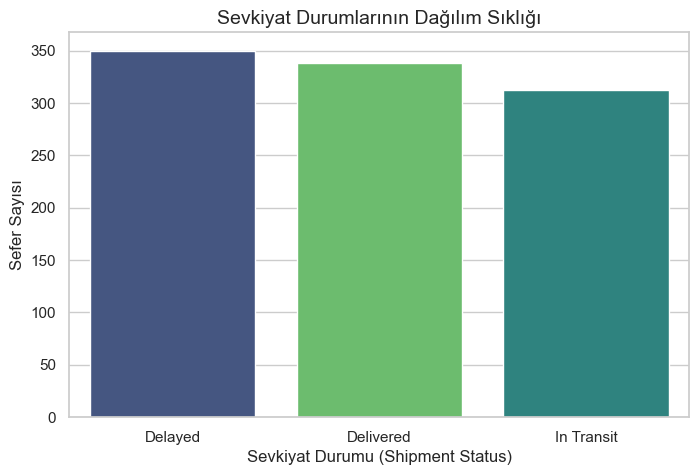

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Doğrudan 'Shipment_Status' sütununu hedef alıyoruz
# Hem x hem hue parametrelerine aynı sütunu vererek yeni sürüm uyarısını engelliyoruz
sns.countplot(
    data=df, 
    x='Shipment_Status', 
    hue='Shipment_Status', 
    palette="viridis", 
    order=df['Shipment_Status'].value_counts().index,
    legend=False
)

plt.title("Sevkiyat Durumlarının Dağılım Sıklığı", fontsize=14)
plt.xlabel("Sevkiyat Durumu (Shipment Status)")
plt.ylabel("Sefer Sayısı")
plt.xticks(rotation=0) # Kategoriler kısa olduğu için eğik yazmaya (45 dereceye) gerek yok, düz yapalım
plt.show()

Grafik bize Delayed, Delivered ve In Transit durumlarının sırasıyla ~350, ~340 ve ~310 sefer sayılarıyla birbirine neredeyse tamamen eşit ve dengeli (homojen) dağıldığını gösteriyor.  Veri biliminde hedef veya sınıfsal kategorilerin bu kadar dengeli dağılması (Balanced Dataset), kuracağımız yapay zeka modeli için muazzam bir avantajdır. Modelimiz, zamanında teslim edilen süreçleri öğrendiği kadar, geciken ve yolda olan süreçleri de eşit ağırlıkta ve tarafsız bir şekilde öğrenebilecek. Bu denge, modelimizin lojistik tahminler yaparken taraflı davranmasını (class imbalance problemini) önleyecek ve aranan kararlı tahmin (robust prediction) yeteneğini sisteme kazandıracaktır.

## 1.7. Eksik Veri (Missing Value) Analizi

Veri setimizde eksik (null) değerlerin olup olmadığını, varsa hangi sütunlarda ve hangi satırlarda yoğunlaştığını yapısal olarak görebilmek adına **Missingno Matrix** görselleştirmesini kullanıyoruz. 

Bu grafikteki **beyaz yatay çizgiler** eksik verileri, **koyu lacivert alanlar** ise dolu verileri temsil eder. Analizimize göre veri setindeki 16 sütundan 15'i tamamen doluyken, sadece gecikme nedenlerini içeren `Logistics_Delay_Reason` sütununda eksik veriler (beyaz çizgiler) bulunmaktadır.

<Figure size 1200x600 with 0 Axes>

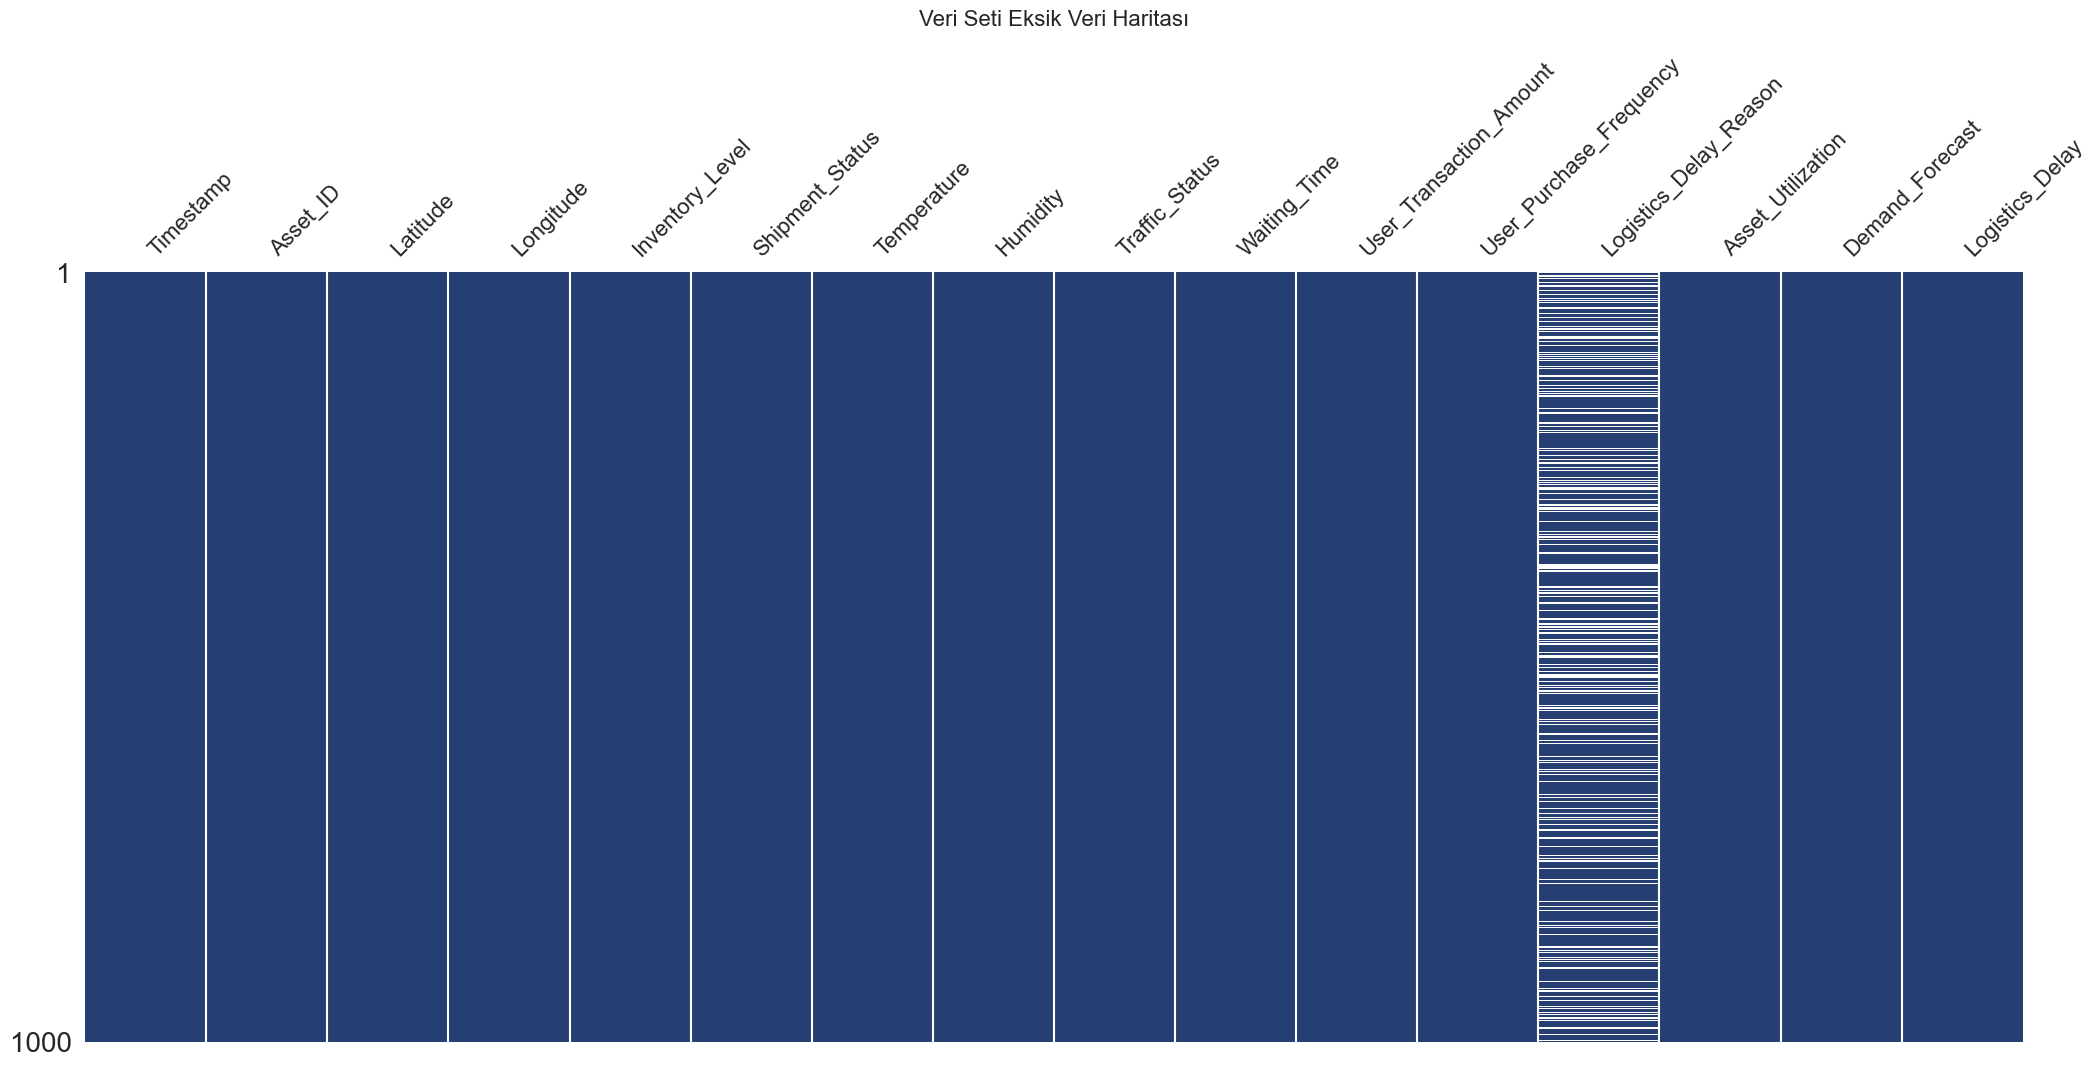

In [16]:
import missingno as msno
import matplotlib.pyplot as plt

# Eksik veri matrisini (barkod grafiğini) çizdiriyoruz
plt.figure(figsize=(12, 6))
msno.matrix(df, sparkline=False, color=(0.15, 0.25, 0.45))
plt.title("Veri Seti Eksik Veri Haritası", fontsize=16, pad=20)
plt.show()

Logistics_Delay_Reason dışındaki tüm lojistik sütunların yukarıdan aşağıya eksiksiz, pürüzsüz koyu lacivert bloklar halinde uzandığını görüyoruz. Sadece gecikme nedenini belirten sütunun üzerinde yatay beyaz çizgilerin yer alması, eksik verilerin sadece bu alanda kümelendiğini görsel olarak kanıtlıyor.  Bu boşlukların sistemsel bir hata değil, sevkiyatın zamanında teslim edilmesinden (Logistics_Delay = 0) kaynaklanan mantıksal sonuçlar olduğunu bildiğimiz için, bir sonraki aşama olan Veri Ön İşleme (Data Preprocessing) kısmında bu satırları silmeyeceğiz. Veri bütünlüğünü korumak adına bu boşlukları 'No Delay' (Gecikme Yok) sabitiyle doldurarak modelimize hazır hale getireceğiz